In [1]:
import json
import torch
from tqdm import tqdm
import torch.nn as nn
import math

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM-135M")

In [3]:
# from transformers import AutoTokenizer, AutoModelForCausalLM

# tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")
# model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B")

In [4]:
gamma_json_file = '/home/tqinmath/WorkSpaces/AZExperiments/src/amzn_az_experiments/td_experiments/DobiSVD/dobi_svd_smollm135_best_gamma.json'
with open(gamma_json_file, 'r') as file:
    gamma_json = json.load(file)

In [5]:
from collections import defaultdict
module_types=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "gate_proj", "down_proj"]
ranks=[]
cfs=defaultdict(float)
for module_type in module_types:
    for name, module in tqdm(model.named_modules(), desc="Add SVD attribute to modules"):
        if isinstance(module, nn.Linear) and module_type in name: 
            gamma = torch.tensor(gamma_json[name])
            m,n =module.weight.shape
            cut = min(n, m)/2048
            if cut>1:
                k = min(m,n, max(1,cut*math.ceil(gamma)))
            else:
                k = min(m,n, max(1,math.ceil(gamma)))
            cf = max(1, m*n/(m*k+n*k))
            cfs[name]=cf

Add SVD attribute to modules: 397it [00:00, 237368.31it/s]
Add SVD attribute to modules: 397it [00:00, 220227.31it/s]
Add SVD attribute to modules: 397it [00:00, 224080.03it/s]
Add SVD attribute to modules: 397it [00:00, 226395.47it/s]
Add SVD attribute to modules: 397it [00:00, 288285.78it/s]
Add SVD attribute to modules: 397it [00:00, 236760.80it/s]
Add SVD attribute to modules: 397it [00:00, 220198.19it/s]


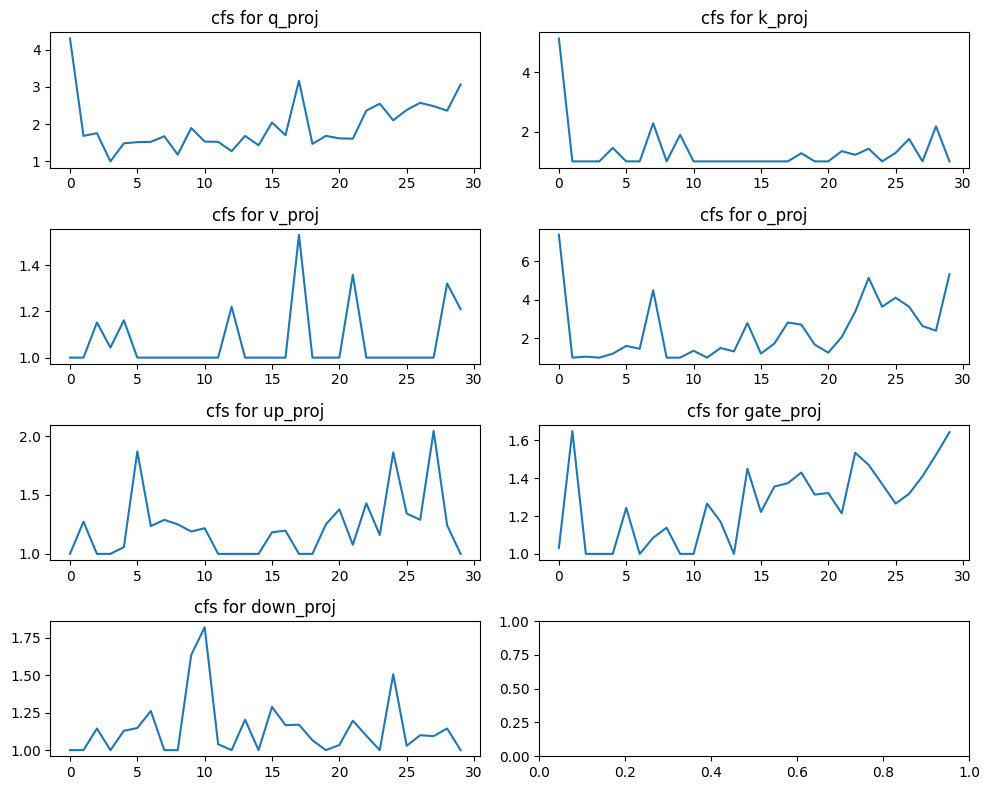

In [10]:
cf_plot={"q_proj":[], "k_proj": [], "v_proj": [], "o_proj":[], "up_proj":[], "gate_proj":[], "down_proj":[]}
for key in cfs:
    module_type=key.split(".")[-1]
    cf_plot[module_type].append(cfs[key])

import matplotlib.pyplot as plt
plt.figure
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 8))

# Plot data on individual subplots
axes[0, 0].plot(cf_plot["q_proj"])
axes[0, 1].plot(cf_plot["k_proj"])
axes[1, 0].plot(cf_plot["v_proj"])
axes[1, 1].plot(cf_plot["o_proj"])
axes[2, 0].plot(cf_plot["up_proj"])
axes[2, 1].plot(cf_plot["gate_proj"])
axes[3, 0].plot(cf_plot["down_proj"])

# Add titles and labels
axes[0, 0].set_title("cfs for q_proj")
axes[0, 1].set_title("cfs for k_proj")
axes[1, 0].set_title("cfs for v_proj")
axes[1, 1].set_title("cfs for o_proj")
axes[2, 0].set_title("cfs for up_proj")
axes[2, 1].set_title("cfs for gate_proj")
axes[3, 0].set_title("cfs for down_proj")

# Adjust spacing between subplots
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
special_shapes={
    'q_proj':{'shape_type': 'out_shape', 'shape':[9, 64]},
    'v_proj':{'shape_type': 'out_shape', 'shape':[3, 64]},
    'k_proj':{'shape_type': 'out_shape', 'shape':[3, 64]},
    'o_proj':{'shape_type': 'in_shape', 'shape':[64, 9]}
}
td_config={}
for key in cfs:
    key_split=key.split('.')
    layer_id=key_split[2]
    module_type=key.split('.')[-1]
    block_type=key.split('.')[-2]
    pattern=f'model\.layers\.{layer_id}\.{block_type}\.{module_type}'
    compression_factor=cfs[key]
    config={
        f"{module_type}_{layer_id}":{
            'find':{
                'pattern': pattern
            },
            'general_replace':{
                'solver_method':{
                    '_target_': 'percipio2.skiboot.td.config.Decomposition.solve_low_ecf',
                    '_partial_': True,
                    'number_cores': 2,
                    'compression_factor': compression_factor,
                    'min_ranks': 10,
                    'topology':'btt'
                },
                'decompose': True
            }
        }
    }
    if module_type in special_shapes:
        special_shape={special_shapes[module_type]['shape_type']:special_shapes[module_type]['shape']}
        config[f"{module_type}_{layer_id}"]['general_replace']['solver_method'].update(special_shape)
    if compression_factor>1:
        td_config.update(config)
hydra_config={"defaults": ["/tensor_decomposition_base"],
              "rules": td_config}

In [ ]:
import yaml
import sys

def generate_hydra_config(td_config, file_path):
    """
    Generates a Hydra config file in YAML format from a Python dictionary.

    Args:
        config_dict (dict): The Python dictionary containing the configuration.
        file_path (str): The path to save the YAML config file.
    """
    with open(file_path, 'w') as file:
        file.write("# @package model.config.percipio.tensor_decomposition\n\n")
        yaml.safe_dump(td_config, file)

In [106]:
file_path="/home/tqinmath/Packages/Percipio2/percipio2/conf/td/smollm_135M_dobi_svd.yaml"
generate_hydra_config(hydra_config,file_path)